<a href="https://colab.research.google.com/github/MartinMCodazzi/Python/blob/main/TP_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
# Librerías necesarias
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Matplotlib: visualizaciones de datos
# https://matplotlib.org/
import matplotlib.pyplot as plt

In [69]:
# Carga del dataset y creación de X e y
dataset = pd.read_csv('dataset_costo_seguro_medico.csv')
X = dataset.iloc[:, :-1]# Todas las filas, todas las columnas menos la última
y = dataset.iloc[:, -1] # Todas las filas, última columna

In [47]:
# Vamos a inspeccionar los primeros datos usando el método head(filas=5)
dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


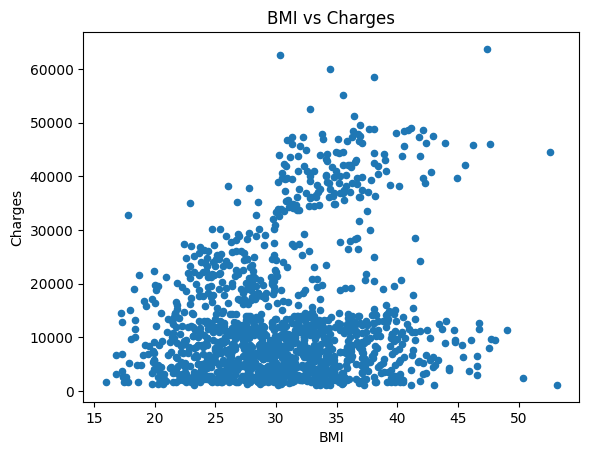

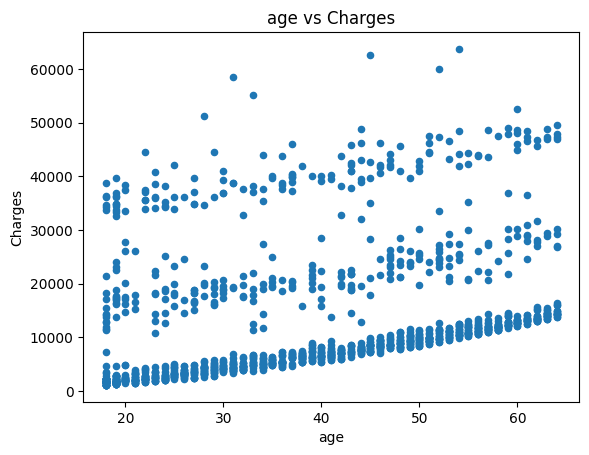

In [71]:
# Uso plot para ver si alguna variable tiene correlación directa con el resultado
# age y charges tienen cierta correlación

dataset.plot.scatter(x='bmi', y='charges')
plt.title('BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

dataset.plot.scatter(x='age', y='charges')
plt.title('age vs Charges')
plt.xlabel('age')
plt.ylabel('Charges')
plt.show()

In [72]:
# Utilizo One Hot para convertir las variables categóricas en variables booleanas
# drop_first sirve para eliminar la primer columna y no caer en la trampa de la variable imaginaria

X = pd.get_dummies(X, columns=['sex', 'smoker', 'region'],drop_first=True)
X.head()

# Una vez que transformé las variables categóricas, debo armar los sets de entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head()


,age,bmi,children,sex_1,smoker_1,region_1,region_2,region_3
560,46,19.95,2,False,False,True,False,False
1285,47,24.32,0,False,False,False,False,False
1142,52,24.86,0,False,False,False,True,False
969,39,34.32,5,False,False,False,True,False
486,54,21.47,3,False,False,True,False,False


In [62]:
#Entreno el modelo con los datos de entrenamiento

modelo = LinearRegression()
modelo.fit(X_train, y_train)

#Chequeo la predicción

y_pred = modelo.predict(X_test)

# Imprimo el MSE y MAE
print ("MAE: ", mean_absolute_error(y_test, y_pred))
print ("MSE: ", mean_squared_error(y_test, y_pred))



MAE:  4181.194473753648
MSE:  33596915.851361446


In [77]:
# Recreo las variables
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

# Transformo las variables categóricas
X = pd.get_dummies(
    X,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

# Separo en sets de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Aplico el escalado
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entreno el modelo
modelo = LinearRegression()

modelo.fit(X_train, y_train)

# Realizo la predicción en base a los casos de prueba
y_pred = modelo.predict(X_test)

# Obtengo las métricas
print("MAE con escalado:", mean_absolute_error(y_test, y_pred))
print("MSE con escalado:", mean_squared_error(y_test, y_pred))

MAE con escalado: 4181.1944737536505
MSE con escalado: 33596915.851361476


*   ¿Qué significa el valor del MAE?

El MAE (Mean Absolute Error) mide la diferencia absoluta promedio entre los valores reales y las predicciones realizadas por el modelo. Un MAE de 4181 indica que, en promedio, las predicciones del modelo difieren aproximadamente en 4181 unidades monetarias respecto de los valores reales.

*   ¿Por qué el MSE es numéricamente mucho más grande que el MAE en este caso?

El MSE es numéricamente mucho más grande que el MAE porque esta métrica eleva los errores al cuadrado antes de calcular el promedio. Esto hace que los errores grandes tengan un impacto mucho mayor sobre el resultado final, mientras que el MAE solamente utiliza el valor absoluto de los errores.

*   ¿Mejora algo al escalar características? ¿Por qué?

El escalado de características no produjo mejoras significativas en las métricas del modelo de regresión lineal, ya que este algoritmo no se basa en distancias entre observaciones sino en relaciones lineales entre variables.
